<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/14_LogisticRegression_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression으로 테슬라(TSLA) 방향성 예측 (분류)
이 노트북은 **주가 수준(연속값)**이 아니라, 다음 거래일의 **상승/하락(이진 분류)** 또는 **상승/보합/하락(다중 분류)**을 예측합니다.

## 핵심 메시지
- Logistic Regression은 **확률을 출력하는 선형 분류기**입니다.
- 시계열에서는 반드시 **시간 순서 보존(train → test)** 과 **정보누수(leakage) 방지**가 중요합니다.
- 성능은 ‘정답률’만 보지 말고, **ROC-AUC(이진), confusion matrix, 기준선(naive) 비교**까지 확인합니다.


## 0) 환경 준비
Colab에서는 기본적으로 sklearn/pandas가 설치되어 있지만, 환경에 따라 아래 설치가 필요할 수 있습니다.
```bash
pip install yfinance
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)


## 1) 데이터 수집
- 기간: **2025-03-30 ~ 2026-03-30 (최근 1년)**
- `auto_adjust=True`로 주가를 분할/배당에 대해 조정한 가격으로 가져옵니다.


In [2]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False)
df = df.reset_index()
print(df.head())
print('Rows:', len(df))


Price        Date       Close        High         Low        Open     Volume
Ticker                   TSLA        TSLA        TSLA        TSLA       TSLA
0      2025-03-31  259.160004  260.559998  243.360001  249.309998  134008900
1      2025-04-01  268.459991  277.450012  259.250000  263.799988  146486900
2      2025-04-02  282.760010  284.989990  251.270004  254.600006  212787800
3      2025-04-03  267.279999  276.299988  261.510010  265.290009  136174300
4      2025-04-04  239.429993  261.000000  236.000000  255.380005  181229400
Rows: 240


## 2) 특징(Feature) 생성
Logistic Regression은 선형 모형이므로, **시계열의 패턴을 ‘특징’으로 만들어서** 제공합니다.

여기서는 최소 구성으로 다음을 사용합니다.
- 과거 수익률(lagged returns)
- 이동평균(MA) 기반 거리
- 변동성(rolling std)

⚠️ **중요:** 모든 특징은 반드시 **과거 정보만** 사용해야 합니다.


In [3]:
df['ret1'] = df['Close'].pct_change()  # 1일 수익률

# Lag features (과거 정보)
for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

# Moving averages
df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0

# Rolling volatility (과거 변동성)
df['vol10'] = df['ret1'].rolling(10).std()

# 결측 제거(초기 구간)
df = df.dropna().reset_index(drop=True)
print('After feature engineering rows:', len(df))


After feature engineering rows: 221


## 3) 타깃 정의
### (A) 이진 분류(상승/하락)
- `y_bin = 1` if 내일 종가가 오늘보다 상승, else 0

### (B) 다중 분류(상승/보합/하락)
- 작은 변동은 ‘보합(0)’로 두고, 상승(+1)/하락(-1) 3클래스로 구성할 수 있습니다.
- 예: 임계치 `thr=0.002`(0.2%)

수업/실습에서는 먼저 (A) 이진부터 안정적으로 돌린 뒤, (B)를 확장하는 것을 권장합니다.


In [4]:
# 다음날 수익률(타깃 만들기용)
df['ret_next'] = df['Close'].pct_change().shift(-1)

# (A) Binary target
df['y_bin'] = (df['ret_next'] > 0).astype(int)

# (B) Multi-class target (optional)
thr = 0.002  # 0.2%
df['y_multi'] = np.where(df['ret_next'] > thr,  1,
                 np.where(df['ret_next'] < -thr, -1, 0))

# 마지막 행은 ret_next가 NaN이므로 제거
df = df.dropna().reset_index(drop=True)
print(df[['Date','Close','ret_next','y_bin','y_multi']].head())


Price        Date       Close  ret_next y_bin y_multi
Ticker                   TSLA                        
0      2025-04-28  285.880005  0.021513     1       1
1      2025-04-29  292.029999 -0.033798     0      -1
2      2025-04-30  282.160004 -0.005812     0      -1
3      2025-05-01  280.519989  0.023849     1       1
4      2025-05-02  287.209991 -0.024198     0      -1


## 4) 학습/테스트 분할 (시간 순서 보존)
- 시계열에서는 랜덤 셔플이 정보누수를 만들 수 있어 `shuffle=False`를 사용합니다.
- 테스트 비율 20% (마지막 구간을 테스트로 사용)


In [5]:
features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']  # 기본: 이진 분류

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (176, 7) Test: (44, 7)


## 5) 모델: Logistic Regression (확률 분류기)
### 왜 스케일링이 필요한가?
- Logistic Regression은 특성 스케일에 민감합니다.
- 따라서 `StandardScaler → LogisticRegression` 파이프라인을 사용합니다.

### 하이퍼파라미터(간단)
- `C`: 규제 강도(작을수록 더 강한 규제)
- `class_weight='balanced'`: 클래스 불균형 완화(옵션)


In [6]:
clf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=2000, C=1.0))
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]


## 6) 평가
이진 분류에서는 아래를 함께 봅니다.
- Accuracy(정확도)
- ROC-AUC(확률 예측의 순위 성능)
- Confusion matrix(오분류 패턴)

⚠️ 단순 기준선(naive)도 함께 봐야 합니다. 예: ‘항상 상승(1) 예측’.


Accuracy: 0.4773
ROC-AUC : 0.4566

Classification report:
              precision    recall  f1-score   support

           0     0.4667    0.3182    0.3784        22
           1     0.4828    0.6364    0.5490        22

    accuracy                         0.4773        44
   macro avg     0.4747    0.4773    0.4637        44
weighted avg     0.4747    0.4773    0.4637        44



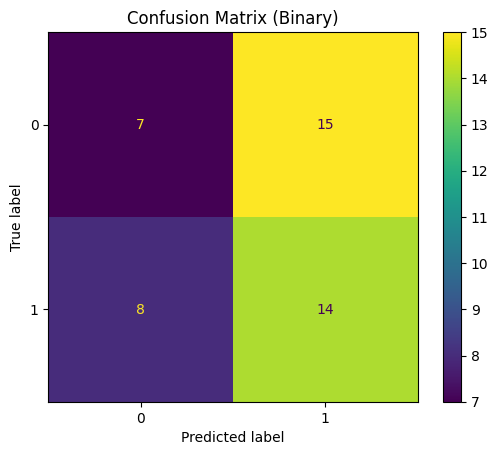

Naive Accuracy (always 1): 0.5000


In [7]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f'Accuracy: {acc:.4f}')
print(f'ROC-AUC : {auc:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='d')
plt.title('Confusion Matrix (Binary)')
plt.show()

# Naive baseline: always predict majority class in train
major = int(pd.Series(y_train).mode()[0])
y_naive = np.full_like(y_test, fill_value=major)
acc_naive = accuracy_score(y_test, y_naive)
print(f'Naive Accuracy (always {major}): {acc_naive:.4f}')


## 7) (선택) 다중 분류로 확장
다중 분류는 `y_multi`를 타깃으로 사용하고, `LogisticRegression(multi_class='auto')`로 학습합니다.
보합(0) 비중이 너무 크면 예측이 ‘보합’으로 쏠릴 수 있으니, 임계치(thr)를 조정해 보세요.


In [8]:
# --- Multi-class optional ---
# y_mc = df['y_multi']
# X_train, X_test, y_train, y_test = train_test_split(X, y_mc, test_size=0.2, shuffle=False)
# clf_mc = Pipeline(steps=[
#     ('scaler', StandardScaler()),
#     ('logit', LogisticRegression(max_iter=3000, C=1.0))
# ])
# clf_mc.fit(X_train, y_train)
# y_pred_mc = clf_mc.predict(X_test)
# print(classification_report(y_test, y_pred_mc, digits=4))


## ✅ 요약(3줄)
1) Logistic Regression은 ‘내일 상승할 확률’을 출력하는 **선형 확률 분류기**입니다.
2) 시계열에서는 **시간 분할**과 **정보누수 방지(스케일러 fit=train만)**가 핵심입니다.
3) 성능은 Accuracy뿐 아니라 **ROC-AUC, confusion matrix, naive baseline**과 함께 해석해야 합니다.

### ➡️ 다음 알고리즘
- Decision Tree / Random Forest로 비선형 경계와 상호작용을 학습하는 버전을 이어서 구현할 수 있습니다.
